# Federated Learning 

> Splits the diabetes dataset into N independent client datasets, simulating hospitals that cannot share raw patient data. Only the model is shared — never the data.

---

## Strategy

Partitioning is done at the **patient level**: all encounters from the same patient go to the same client, so no patient can appear in two hospitals simultaneously. This prevents data leakage across clients.

| Stage | What it does |
|---|---|
| **1. Global schema** | Runs `prepare_data` once on the full dataset to learn the complete dummy column space |
| **2. Partition** | Shuffles patient IDs, splits into N chunks, writes each client's raw rows to disk |
| **3. Client prep** | Each client independently preprocesses, splits and scales its own data |

The only information shared between stages is `feature_schema.json` — a list of column names with no patient data — which guarantees identical feature dimensionality across all clients.

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib
import json
import os

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, roc_auc_score,
    classification_report
)
from xgboost import XGBClassifier
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import sys
sys.path.append('..')

from UC1Utils import (
    prepare_data, ensure_data,
    prepare_data_aligned, derive_global_columns,
    split_data, scale_data,
    DATA_DIR, CSV_MAIN  
)

DATA_PATH  = CSV_MAIN  
OUTPUT_DIR = 'federated_data'
N_CLIENTS  = 5
SEED       = 42

ensure_data()

✓ CSV files already present, skipping extraction.


## Global Feature Schema

Run `prepare_data` once on the full dataset to discover the complete set of dummy columns that `get_dummies` would produce across all patients. This list becomes the shared contract that every client aligns to after their independent preprocessing.

This is the **only** step that touches the full dataset. Nothing here is shared with clients except the column names.

In [3]:
global_columns = derive_global_columns(DATA_PATH)

os.makedirs(OUTPUT_DIR, exist_ok=True)
schema_path = os.path.join(OUTPUT_DIR, 'feature_schema.json')
with open(schema_path, 'w') as f:
    json.dump(global_columns, f, indent=2)

print(f'Feature schema saved → {schema_path}')

Deriving global feature schema from full dataset...
  87 feature columns
Feature schema saved → federated_data/feature_schema.json


## Partition of Data into Clients

Shuffle all unique patient IDs with a seeded RNG and cut them into N equal chunks. Each client receives only its raw rows — no preprocessing happens here.

In [6]:
df_raw          = pd.read_csv(DATA_PATH)
unique_patients = df_raw['patient_nbr'].unique()

print(f'Total rows      : {len(df_raw):,}')
print(f'Unique patients : {len(unique_patients):,}')

rng      = np.random.default_rng(SEED)
shuffled = rng.permutation(unique_patients)
chunks   = np.array_split(shuffled, N_CLIENTS)

Total rows      : 101,766
Unique patients : 71,518


In [7]:
manifest = {}

for i, patient_ids in enumerate(chunks):
    client_dir = os.path.join(OUTPUT_DIR, f'client_{i}')
    os.makedirs(client_dir, exist_ok=True)

    client_df = df_raw[df_raw['patient_nbr'].isin(patient_ids)].copy()
    raw_path  = os.path.join(client_dir, 'raw_data.csv')
    client_df.to_csv(raw_path, index=False)

    manifest[f'client_{i}'] = {
        'n_patients'  : int(len(patient_ids)),
        'n_encounters': int(len(client_df)),
        'raw_data'    : raw_path,
    }
    print(f'  client_{i}: {len(patient_ids):>6,} patients | {len(client_df):>7,} encounters')

manifest_path = os.path.join(OUTPUT_DIR, 'manifest.json')
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
print(f'\nManifest saved → {manifest_path}')

  client_0: 14,304 patients |  20,509 encounters
  client_1: 14,304 patients |  20,280 encounters
  client_2: 14,304 patients |  20,515 encounters
  client_3: 14,303 patients |  20,314 encounters
  client_4: 14,303 patients |  20,148 encounters

Manifest saved → federated_data/manifest.json


In [8]:
# Verify zero patient leakage across all client pairs
print('Verifying zero patient leakage...')
all_sets = [set(chunk) for chunk in chunks]
for a in range(N_CLIENTS):
    for b in range(a + 1, N_CLIENTS):
        overlap = all_sets[a] & all_sets[b]
        assert len(overlap) == 0, \
            f'LEAK between client_{a} and client_{b}: {len(overlap)} patients'
print('✓ Zero leakage confirmed.')

Verifying zero patient leakage...
✓ Zero leakage confirmed.


## Client Preparation

Each client independently preprocesses its own raw CSV. No client has access to another client's data — the loop here simply simulates what would run on separate machines in a real deployment.

Each iteration:
1. Calls `prepare_data_aligned` on its own `raw_data.csv` — identical pipeline to the centralized baseline, plus schema alignment
2. Splits into train / val / test at the patient level
3. Fits a `StandardScaler` on its own training data only
4. Saves arrays, scaler and stats to its folder

In [9]:
client_info = {}

for i in range(N_CLIENTS):
    client_dir = os.path.join(OUTPUT_DIR, f'client_{i}')
    raw_path   = os.path.join(client_dir, 'raw_data.csv')
    print(f'\n── client_{i} {"─" * 50}')

    # Preprocess independently — aligned to global schema
    X, y, groups, feature_names = prepare_data_aligned(
        path           = raw_path,
        global_columns = global_columns,
        verbose        = True,
    )

    # Patient-level train / val / test split
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X, y, groups, test_size=0.2, val_size=0.15, seed=SEED
    )
    print(f'Split  → train: {len(X_train):,} | val: {len(X_val):,} | test: {len(X_test):,}')

    # Scale — fitted on this client's train only
    X_train_s, X_val_s, X_test_s, scaler = scale_data(X_train, X_val, X_test)

    # Save
    np.save(os.path.join(client_dir, 'X_train.npy'), X_train_s)
    np.save(os.path.join(client_dir, 'X_val.npy'),   X_val_s)
    np.save(os.path.join(client_dir, 'X_test.npy'),  X_test_s)
    np.save(os.path.join(client_dir, 'y_train.npy'), y_train)
    np.save(os.path.join(client_dir, 'y_val.npy'),   y_val)
    np.save(os.path.join(client_dir, 'y_test.npy'),  y_test)
    joblib.dump(scaler, os.path.join(client_dir, 'scaler.joblib'))

    info = {
        'n_train'      : int(len(X_train)),
        'n_val'        : int(len(X_val)),
        'n_test'       : int(len(X_test)),
        'n_features'   : int(X_train_s.shape[1]),
        'positive_rate': float(round(float(y_train.mean()), 4)),
    }
    with open(os.path.join(client_dir, 'client_info.json'), 'w') as f:
        json.dump(info, f, indent=2)

    client_info[f'client_{i}'] = info
    print(f'Positive rate  → {info["positive_rate"]:.3f}')
    print(f'Saved          → {client_dir}/')


── client_0 ──────────────────────────────────────────────────
dropna removed 335 rows (1.67%)
Dataset shape after cleaning: (19730, 89)
Class distribution:
readmitted_binary
0    17443
1     2287
Name: count, dtype: int64
Split  → train: 13,483 | val: 2,362 | test: 3,885
Positive rate  → 0.115
Saved          → federated_data/client_0/

── client_1 ──────────────────────────────────────────────────
dropna removed 320 rows (1.62%)
Dataset shape after cleaning: (19470, 89)
Class distribution:
readmitted_binary
0    17260
1     2210
Name: count, dtype: int64
Split  → train: 13,213 | val: 2,379 | test: 3,878
Positive rate  → 0.113
Saved          → federated_data/client_1/

── client_2 ──────────────────────────────────────────────────
dropna removed 291 rows (1.45%)
Dataset shape after cleaning: (19734, 89)
Class distribution:
readmitted_binary
0    17499
1     2235
Name: count, dtype: int64
Split  → train: 13,419 | val: 2,417 | test: 3,898
Positive rate  → 0.113
Saved          → federate


─────────────────────────────────────────────────────────────────
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0     13,483    2,362    3,885         87      0.115
  client_1     13,213    2,379    3,878         87      0.113
  client_2     13,419    2,417    3,898         87      0.113
  client_3     13,272    2,309    3,909         87      0.114
  client_4     13,181    2,287    3,933         87      0.113


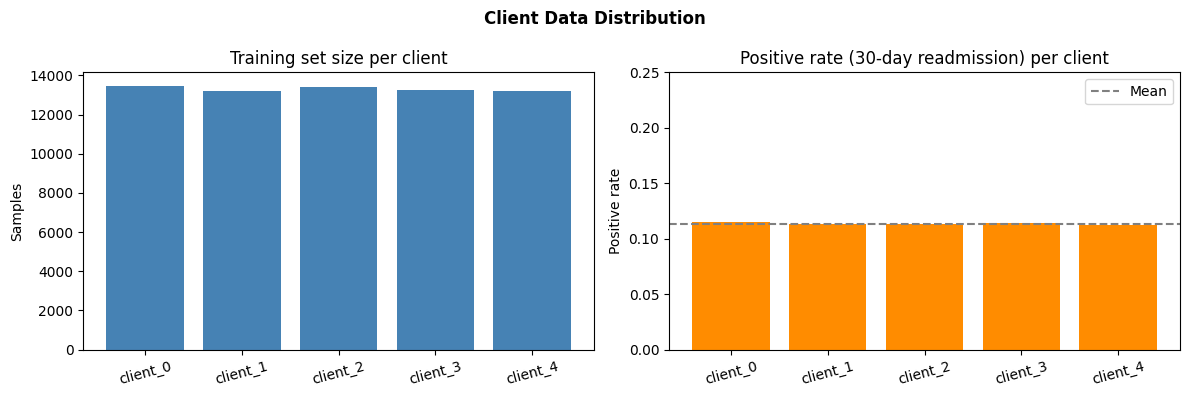

In [ ]:
print(f'\n{"─" * 65}')
print(f'  {"Client":<10} {"Train":>8} {"Val":>8} {"Test":>8} {"Features":>10} {"Pos. rate":>10}')
print(f'  {"─"*10} {"─"*8} {"─"*8} {"─"*8} {"─"*10} {"─"*10}')
for k, v in client_info.items():
    print(f'  {k:<10} {v["n_train"]:>8,} {v["n_val"]:>8,} '
          f'{v["n_test"]:>8,} {v["n_features"]:>10,} {v["positive_rate"]:>10.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Client Data Distribution', fontweight='bold')

clients_keys     = list(client_info.keys())
train_sizes = [client_info[c]['n_train'] for c in clients_keys]
pos_rates   = [client_info[c]['positive_rate'] for c in clients_keys]

axes[0].bar(clients_keys, train_sizes, color='steelblue')
axes[0].set_title('Training set size per client')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(clients_keys, pos_rates, color='darkorange')
axes[1].axhline(sum(pos_rates) / len(pos_rates), color='gray',
                linestyle='--', label='Mean')
axes[1].set_title('Positive rate (30-day readmission) per client')
axes[1].set_ylabel('Positive rate')
axes[1].set_ylim(0, 0.25)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'client_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## Model Setup

In [11]:
# ── MLP definition (identical to centralized baseline) ────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
# Load best params from the centralized MLP checkpoint
centralized_ckpt = torch.load('../Centralized/models/mlp_centralized.pt', map_location=device, weights_only=False)

best_p = centralized_ckpt['best_params']

FL_ROUNDS    = 10
LOCAL_EPOCHS = 5
HIDDEN_DIM   = best_p['hidden_dim']
DROPOUT      = best_p['dropout']
LR           = best_p['lr']
BATCH_SIZE   = best_p['batch_size']

print(f"Loaded from centralized checkpoint:")
print(f"  hidden_dim : {HIDDEN_DIM}")
print(f"  dropout    : {DROPOUT:.4f}")
print(f"  lr         : {LR:.6f}")
print(f"  batch_size : {BATCH_SIZE}")

Loaded from centralized checkpoint:
  hidden_dim : 128
  dropout    : 0.3438
  lr         : 0.001694
  batch_size : 512


## FedAvg

In [15]:
# ── Local training function ───────────────────────────────────────────────────
def local_train(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """
    Train model on one client's data for a fixed number of epochs.
    Returns the updated state dict and the number of training samples.
    """
    loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size, shuffle=True
    )

    cw = compute_class_weight(
        'balanced',
        classes=np.unique(y_train.numpy()),
        y=y_train.numpy()
    )
    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(cw, dtype=torch.float32).to(device)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val_loss = float('inf')
    best_state    = None

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(
                model(X_val.to(device)),
                y_val.to(device)
            ).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    return best_state, len(X_train)


# ── FedAvg aggregation ────────────────────────────────────────────────────────
def fed_avg(state_dicts, sample_counts):
    """
    Weighted average of model parameters.
    Each client's contribution is proportional to its number of training samples.
    """
    total = sum(sample_counts)
    avg_state = {}

    for key in state_dicts[0].keys():
        avg_state[key] = sum(
            state_dicts[i][key] * (sample_counts[i] / total)
            for i in range(len(state_dicts))
        )

    return avg_state

In [17]:
# ── Federation loop ───────────────────────────────────────────────────────────
# Initialise one global model — all clients start from the same weights

input_dim= client_info['client_0']['n_features']  # All clients have the same feature count after alignment
global_model = MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)

clients = {}

for i in range(N_CLIENTS):
    client_dir = os.path.join(OUTPUT_DIR, f'client_{i}')
    clients[i] = {
        'X_train': torch.tensor(np.load(os.path.join(client_dir, 'X_train.npy')), dtype=torch.float32),
        'y_train': torch.tensor(np.load(os.path.join(client_dir, 'y_train.npy')), dtype=torch.long),
        'X_val'  : torch.tensor(np.load(os.path.join(client_dir, 'X_val.npy')),   dtype=torch.float32),
        'y_val'  : torch.tensor(np.load(os.path.join(client_dir, 'y_val.npy')),   dtype=torch.long),
        'X_test' : torch.tensor(np.load(os.path.join(client_dir, 'X_test.npy')),  dtype=torch.float32),
        'y_test' : torch.tensor(np.load(os.path.join(client_dir, 'y_test.npy')),  dtype=torch.long),
    }
    print(f'client_{i}: {len(clients[i]["y_train"]):,} train samples')

round_aucs = []  # global AUC after each round

for fl_round in range(FL_ROUNDS):
    print(f'\n─── Round {fl_round + 1}/{FL_ROUNDS} ───────────────────────────')

    state_dicts   = []
    sample_counts = []

    # ── Local training on each client ────────────────────────────────────────
    for i in range(N_CLIENTS):
        # Each client gets a copy of the current global model
        local_model = MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
        local_model.load_state_dict(global_model.state_dict())

        state, n = local_train(
            model      = local_model,
            X_train    = clients[i]['X_train'],
            y_train    = clients[i]['y_train'],
            X_val      = clients[i]['X_val'],
            y_val      = clients[i]['y_val'],
            epochs     = LOCAL_EPOCHS,
            batch_size = BATCH_SIZE,
        )
        state_dicts.append(state)
        sample_counts.append(n)
        print(f'  client_{i}: trained on {n:,} samples')

    # ── Aggregate ─────────────────────────────────────────────────────────────
    global_state = fed_avg(state_dicts, sample_counts)
    global_model.load_state_dict(global_state)

    # ── Global evaluation (simulation only — concatenate all test sets) ───────
    global_model.eval()
    all_proba = []
    all_y     = []

    with torch.no_grad():
        for i in range(N_CLIENTS):
            logits = global_model(clients[i]['X_test'].to(device))
            proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_proba.append(proba)
            all_y.append(clients[i]['y_test'].numpy())

    all_proba = np.concatenate(all_proba)
    all_y     = np.concatenate(all_y)
    auc       = roc_auc_score(all_y, all_proba)
    round_aucs.append(auc)
    print(f'  Global AUC: {auc:.4f}')

client_0: 13,483 train samples
client_1: 13,213 train samples
client_2: 13,419 train samples
client_3: 13,272 train samples
client_4: 13,181 train samples

─── Round 1/10 ───────────────────────────
  client_0: trained on 13,483 samples
  client_1: trained on 13,213 samples
  client_2: trained on 13,419 samples
  client_3: trained on 13,272 samples
  client_4: trained on 13,181 samples
  Global AUC: 0.6490

─── Round 2/10 ───────────────────────────
  client_0: trained on 13,483 samples
  client_1: trained on 13,213 samples
  client_2: trained on 13,419 samples
  client_3: trained on 13,272 samples
  client_4: trained on 13,181 samples
  Global AUC: 0.6552

─── Round 3/10 ───────────────────────────
  client_0: trained on 13,483 samples
  client_1: trained on 13,213 samples
  client_2: trained on 13,419 samples
  client_3: trained on 13,272 samples
  client_4: trained on 13,181 samples
  Global AUC: 0.6573

─── Round 4/10 ───────────────────────────
  client_0: trained on 13,483 sample

In [18]:
# ── Per-client evaluation with final global model ─────────────────────────────
print('\n=== Per-client results (final global model) ===')
global_model.eval()

with torch.no_grad():
    for i in range(N_CLIENTS):
        logits = global_model(clients[i]['X_test'].to(device))
        proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        auc    = roc_auc_score(clients[i]['y_test'].numpy(), proba)
        print(f'\nclient_{i} — AUC: {auc:.4f}')
        print(classification_report(clients[i]['y_test'].numpy(), preds))


=== Per-client results (final global model) ===

client_0 — AUC: 0.6740
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      3448
           1       0.18      0.60      0.28       437

    accuracy                           0.65      3885
   macro avg       0.55      0.63      0.52      3885
weighted avg       0.84      0.65      0.71      3885


client_1 — AUC: 0.6792
              precision    recall  f1-score   support

           0       0.93      0.64      0.76      3447
           1       0.18      0.62      0.28       431

    accuracy                           0.64      3878
   macro avg       0.55      0.63      0.52      3878
weighted avg       0.85      0.64      0.70      3878


client_2 — AUC: 0.6569
              precision    recall  f1-score   support

           0       0.93      0.66      0.77      3476
           1       0.17      0.59      0.27       422

    accuracy                           0.65      3898
   macr